<a href="https://colab.research.google.com/github/aryasaidwork03-byte/data-analytics-portfolio/blob/main/Proyek_Portofolio_Klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Function

## Select Column

In [ ]:
def select_columns(df: pd.DataFrame, features: list, target: list):
  x = df[features]
  y = df[target].astype(str)

  return x,y

# Preprocessing Data

## Import library

In [ ]:
import pandas as pd #untuk analisis data
import numpy as np #untuk operasi matematik
import matplotlib.pyplot as plt #untuk visualisasi data
import seaborn as sns #untuk visualisasi data

## Load Dataset

In [ ]:
# Connect to gdrive

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


### Movies Data

In [ ]:
# Import data
movies_data = pd.read_csv("/content/gdrive/MyDrive/Statistika UNS /MySkill/Data Science/Understanding data : Movie/movies_metadata.csv")

In [ ]:
# Menampilkan informasi mengenai data
movies_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45463 entries, 0 to 45462
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45463 non-null  bool   
 1   belongs_to_collection  4491 non-null   object 
 2   budget                 45463 non-null  int64  
 3   genres                 45463 non-null  object 
 4   homepage               7779 non-null   object 
 5   id                     45463 non-null  int64  
 6   imdb_id                45446 non-null  object 
 7   original_language      45452 non-null  object 
 8   original_title         45463 non-null  object 
 9   overview               44509 non-null  object 
 10  popularity             45460 non-null  float64
 11  poster_path            45077 non-null  object 
 12  production_companies   45460 non-null  object 
 13  production_countries   45460 non-null  object 
 14  release_date           45376 non-null  object 
 15  re

Informasi movies_data :
- data yang berisikan ratings dari 45463 film yang bersumber dari situs IMDb
- berisikan 24 atribute meliputi =
  1. 'adult' : jenis rating film (untuk dewasa atau anak-anak)
  2. 'belongs_to_collection' : sekuel film
  3. 'budget' : biaya produksi yang digunakan
  4. 'genres' : genre film
  5. 'homepage' : tautan web dari film
  6. 'id' : nomor id film
  7. 'imdb_id' : nomor id film di imdb
  8. 'original_language' : bahasa yang digunakan
  9. 'original_title' : judul asli
  10. 'overview' : sinopsis
  11. 'popularity' : tingkat popularitas
  12. 'poster_path' : tautan poster
  13. 'production_companies' : perusahaan produksi
  14. 'production_countries' : asal negara produksi
  15. 'release_date' : tanggal rilis
  16. 'revenue' : pendapatan
  17. 'runtime' : durasi
  18. 'spoken_languages' : bahasa
  19. 'status' : status rilis
  20. 'tagline' : tagline film
  21. 'title' : judul film
  22. 'video':
  23. 'vote_average' : rata-rata penilaian
  24. 'vote_count' : jumlah penilaian


dari data tersebut diambil data film yang sudah dirilis

In [ ]:
movies_release = movies_data[movies_data["status"]=="Released"]
movies_release

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,True,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,True,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,True,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,True,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,True,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45458,True,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10751, 'n...",http://www.imdb.com/title/tt6209470/,439050,tt6209470,fa,رگ خواب,Rising and falling between a man and woman.,...,NaN,0.0,90.0,"[{'iso_639_1': 'fa', 'name': 'فارسی'}]",Released,Rising and falling between a man and woman,Subdue,False,4.0,1.0
45459,True,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,111109,tt2028550,tl,Siglo ng Pagluluwal,An artist struggles to finish his work while a...,...,2011-11-17,0.0,360.0,"[{'iso_639_1': 'tl', 'name': ''}]",Released,NaN,Century of Birthing,False,9.0,3.0
45460,True,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",NaN,67758,tt0303758,en,Betrayal,"When one of her hits goes wrong, a professiona...",...,2003-08-01,0.0,90.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A deadly game of wits.,Betrayal,False,3.8,6.0
45461,True,NaN,0,[],NaN,227506,tt0008536,en,Satana likuyushchiy,"In a small town live two brothers, one a minis...",...,1917-10-21,0.0,87.0,[],Released,NaN,Satan Triumphant,False,0.0,0.0


### Ratings Data

In [ ]:
# Load dataset rating

rating = pd.read_csv("/content/gdrive/MyDrive/Statistika UNS /MySkill/Data Science/Understanding data : Movie/ratings_small.csv")
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


informasi rating :
- merupakan dataset yang berisi penilaian user terhadap sebuah film
- berisi 4 atribute meliputi :
  1. 'userId' : nomor id dari pemberi nilai
  2. 'movieId' : nomor id dari film
  3. 'rating' : jumlah penilaian
  5. 'timestamp' : waktu pemberian nilai

data tersebut diagregasikan untuk menampilkan rata-rata vote yang diperoleh masing-masing film

In [ ]:
#  agregasi data
movies_rating = rating.groupby("movieId")["rating"].agg(["mean","count"])
movies_rating

,mean,count
movieId,,
1,3.872470,247
2,3.401869,107
3,3.161017,59
4,2.384615,13
5,3.267857,56
...,...,...
161944,5.000000,1
162376,4.500000,1
162542,5.000000,1


## Penggabungan 2 dataset

Menggabungkan dataset "movies_release" dan "rating"

In [ ]:
movies_rrating = movies_release.merge(movies_rating,
                                      left_on = "id",
                                      right_on = "movieId",
                                      how = "inner")
movies_rrating

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,mean,count
0,True,NaN,60000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,3.593750,16
1,True,"{'id': 645, 'name': 'James Bond Collection', '...",58000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.mgm.com/view/movie/757/Goldeneye/,710,tt0113189,en,GoldenEye,James Bond must unmask the mysterious head of ...,...,130.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,No limits. No fears. No substitutes.,GoldenEye,False,6.6,1194.0,1.500000,2
2,True,NaN,98000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",NaN,1408,tt0112760,en,Cutthroat Island,"Morgan Adams and her slave, William Shaw, are ...",...,119.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,The Course Has Been Set. There Is No Turning B...,Cutthroat Island,False,5.7,137.0,3.616279,43
3,True,NaN,52000000,"[{'id': 18, 'name': 'Drama'}, {'id': 80, 'name...",NaN,524,tt0112641,en,Casino,The life of the gambling paradise – Las Vegas ...,...,178.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,No one stays at the top forever.,Casino,False,7.8,1343.0,3.555556,36
4,True,NaN,16500000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,4584,tt0114388,en,Sense and Sensibility,"Rich Mr. Dashwood dies, leaving his second wif...",...,136.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Lose your heart and come to your senses.,Sense and Sensibility,False,7.2,364.0,5.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2813,True,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,80831,tt1576459,en,Sang Pemimpi,This movie is an adaptation from a popular nov...,...,121.0,"[{'iso_639_1': 'id', 'name': 'Bahasa indonesia'}]",Released,NaN,Sang Pemimpi,False,6.5,2.0,3.250000,4
2814,True,"{'id': 123720, 'name': 'Frankenstein (Hammer S...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,3104,tt0061683,en,Frankenstein Created Woman,A deformed tormented girl drowns herself after...,...,92.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Now Frankenstein has created a beautiful woman...,Frankenstein Created Woman,False,5.9,33.0,3.965517,29
2815,True,NaN,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 18, ...",NaN,64197,tt1047845,ru,Puteshestvie s domashnimi zhivotnymi,Plucked from an orphanage as a literal love sl...,...,97.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Travelling with Pets,False,6.0,5.0,4.166667,3
2816,True,NaN,0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,98604,tt2147597,ru,Zolushka,"Masha Krapivina - is yet beautiful, and not th...",...,91.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Cinderella,False,4.6,6.0,4.000000,1


## Pembuatan feature "good"
menggolongkan fil dalam kategori bagus dan tidak.
- bagus = rating > 3
- buruk = rating < 3

In [ ]:
movies_rrating["good"] = movies_rrating["mean"] > 3

In [ ]:
movies_rrating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  2818 non-null   bool   
 1   belongs_to_collection  538 non-null    object 
 2   budget                 2818 non-null   int64  
 3   genres                 2818 non-null   object 
 4   homepage               579 non-null    object 
 5   id                     2818 non-null   int64  
 6   imdb_id                2818 non-null   object 
 7   original_language      2818 non-null   object 
 8   original_title         2818 non-null   object 
 9   overview               2797 non-null   object 
 10  popularity             2818 non-null   float64
 11  poster_path            2814 non-null   object 
 12  production_companies   2818 non-null   object 
 13  production_countries   2818 non-null   object 
 14  release_date           2817 non-null   object 
 15  reve

## Data Cleansing

### Pembersihan data pada feature "count"

Terdapat anomali data yaitu pada satu film terdapat 1 pemberian nilai sata yang menghasilkan rating menjadi 5 sehingga menyebabkan bias pada rating.

In [ ]:
# statistik deskriptif dari feature "count"
movies_rrating["count"].describe()

,count
count,2818.000000
mean,15.947126
std,31.012789
min,1.000000
25%,1.000000
50%,4.000000
75%,15.000000
max,324.000000


In [ ]:
movies_rrating.groupby("count")["count"].size()

,count
count,
1,748
2,334
3,202
4,179
5,133
...,...
274,1
291,1
304,1


In [ ]:
# nilai unik dari jumlah voter tiap film
movies_rrating["count"].unique()

array([ 16,   2,  43,  36,   1,  56,   4,   7,  44,   6,  76,  25,   5,
        10,  13,   3,   8,  18,  19,  15,  47,  34,   9,  50,  82,  29,
       244,  17, 228,  35,  24,  42,  60,  22,  12,  32,  38,  54,  11,
       104, 114,  68,  27, 200,  30,  31,  33,  39,  26,  14,  87, 109,
        20, 291,  51,  70, 110,  23,  41, 153,  40, 102, 176, 125,  21,
        28,  78,  48,  69, 101, 107,  66,  75,  49, 180,  62,  83,  59,
       117,  65,  73, 147, 129,  93, 198,  92, 142,  55,  90,  95, 190,
       193,  52,  64, 191,  37,  63,  58,  72,  94, 148,  98,  97, 132,
       131, 123,  46,  89, 304, 146, 196,  61,  88,  71, 311, 118,  79,
        53,  80, 130, 274,  45, 224,  74, 137, 202, 324, 126,  86, 218,
       168, 124,  57,  85, 145, 106,  84, 105, 175, 113, 115, 158,  67,
       215, 112, 165, 164,  99,  81, 119, 108, 120, 213, 161, 121])

In [ ]:
x = {'count_unique' : list(movies_rrating["count"].unique())}
dfx = pd.DataFrame(x)
dfx["count_unique"].describe()


,count_unique
count,155.000000
mean,92.180645
std,69.294635
min,1.000000
25%,39.500000
50%,79.000000
75%,124.500000
max,324.000000


anomali tersebut dapat diatasi dengan menghapus data film yang dinilai oleh < 1/3 atau q1 dari nilai unik jumlah voter tiap film yaitu 39.5

In [ ]:
data_unbiased = (movies_rrating[movies_rrating["count"]>39.5])

## Cek duplikasi data

In [ ]:
data_unbiased["id"].duplicated().sum()

0

tidak ada duplikasi pada data

### menentukan data yang akan digunakan

pada proses pengklasifikasian kali ini akan menggunakan feature berupa ["budget", "popularity", "runtime"] dan targetnya adalah "good"

In [ ]:
new_df = data_unbiased[["id","good", "popularity", "runtime", "budget"]]
new_df

,id,good,popularity,runtime,budget
2,1408,True,7.284477,119.0,98000000
5,5,True,9.026586,98.0,4000000
8,902,True,9.822423,108.0,18000000
12,2054,False,7.137117,137.0,0
37,1909,True,7.438934,97.0,25000000
...,...,...,...,...,...
2764,4369,True,2.607919,88.0,0
2776,48780,True,0.479388,8.0,0
2792,68954,True,6.051227,198.0,0
2793,3210,True,0.720828,77.0,0


## mengecek dan menangani missing value

In [ ]:
new_df.isna().sum()

,0
id,0
good,0
popularity,0
runtime,0
budget,0


tidak ada missing value pada data

## Menghilangkan data yang memiliki nilai "budget" 0

In [ ]:
new_df = new_df[new_df["budget"]>0]

## Data Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# menentukan target dan feature
features = ["budget", "popularity", "runtime"]
target = "good"
x, y = select_columns(new_df, features = features, target = target)

In [ ]:
# pembagian data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42) # 42 berfungsi untuk menyamakan pengacakan tiap runtime

## Transformasi Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# transformasi data
x_train_scaled = MinMaxScaler().fit_transform(x_train)
x_test_scaled = MinMaxScaler().fit_transform(x_test)
x_train_scaled, x_test_scaled

(array([[3.98079616e-02, 4.07487467e-01, 8.10810811e-02],
        [7.99959992e-01, 2.99548674e-01, 3.69369369e-01],
        [1.74834967e-01, 4.82703816e-01, 2.52252252e-01],
        [1.00000000e+00, 7.97986225e-01, 6.39639640e-01],
        [2.99859972e-01, 3.76940530e-01, 4.32432432e-01],
        [6.48129626e-02, 8.48804851e-02, 8.37837838e-01],
        [1.48029606e-02, 1.29286876e-01, 1.44144144e-01],
        [8.98179636e-02, 2.59915797e-01, 2.52252252e-01],
        [1.23024605e-02, 2.46387881e-01, 3.06306306e-01],
        [1.19823965e-01, 3.10446654e-01, 9.90990991e-02],
        [1.42429986e-02, 9.84790005e-02, 2.70270270e-01],
        [3.49869974e-01, 3.94689306e-01, 4.05405405e-01],
        [1.19823965e-01, 3.35956262e-01, 3.51351351e-01],
        [2.53492198e-03, 1.80509557e-01, 5.40540541e-01],
        [1.08021604e-02, 4.59714463e-01, 5.04504505e-01],
        [6.49929986e-01, 2.15216019e-01, 6.03603604e-01],
        [1.85537107e-02, 2.04593776e-01, 3.51351351e-01],
        [2.748

berdasarkan preprocessing data, data siap digunakan untuk pemodelan

# Supervised Machine Learning

## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors= 2)

In [ ]:
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=2)

In [ ]:
y_train_predknn = knn.predict(x_train_scaled)

In [ ]:
pd.crosstab(y_train, y_train_predknn)

col_0,False,True
good,,
False,13,0
True,15,105


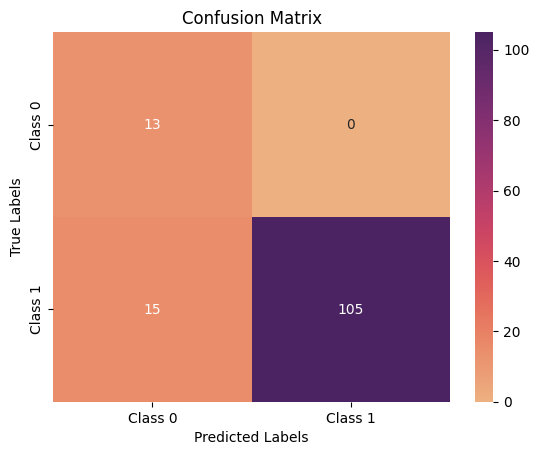

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(y_train, y_train_predknn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='flare', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier()

In [ ]:
dt.fit(x_train_scaled, y_train)

DecisionTreeClassifier()

In [ ]:
y_train_preddt = dt.predict(x_train_scaled)

In [ ]:
pd.crosstab(y_train, y_train_preddt)

col_0,False,True
good,,
False,13,0
True,0,120


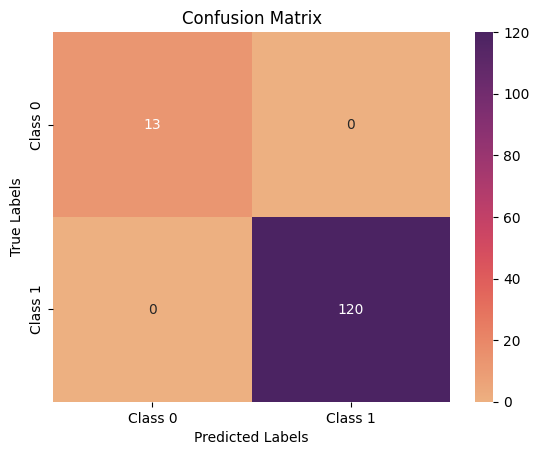

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix
cm_dt = confusion_matrix(y_train, y_train_preddt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='flare', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Evaluasi Model

In [ ]:
from sklearn.metrics import classification_report

## KNN

In [ ]:
# data training
print(classification_report(y_train, y_train_predknn))

              precision    recall  f1-score   support

       False       0.46      1.00      0.63        13
        True       1.00      0.88      0.93       120

    accuracy                           0.89       133
   macro avg       0.73      0.94      0.78       133
weighted avg       0.95      0.89      0.90       133



In [ ]:
# data testing
y_test_predknn = knn.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test, y_test_predknn))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00         3
        True       0.94      0.87      0.90        54

    accuracy                           0.82        57
   macro avg       0.47      0.44      0.45        57
weighted avg       0.89      0.82      0.86        57



Hasil evaluasi model klasifikasi metode KNN menunjukkan bahwa tidak terdapat perbedaan terlalu jauh antara nilai presisi, recall, f1-score dan akurasi antara data training dan data testing. Hal tersebut menunjukkan bahwa model knn yang dihasilkan tidak mengalami overfitting maupun underfitting. metode klasifikasi knn dengan n = 2 merupakan model yang baik

## Decision Tree

In [ ]:
# data training
print(classification_report(y_train, y_train_preddt))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        13
        True       1.00      1.00      1.00       120

    accuracy                           1.00       133
   macro avg       1.00      1.00      1.00       133
weighted avg       1.00      1.00      1.00       133



In [ ]:
# data testing
y_test_preddt = dt.predict(x_test_scaled)

In [ ]:
print(classification_report(y_test, y_test_preddt))

              precision    recall  f1-score   support

       False       0.00      0.00      0.00         3
        True       0.94      0.93      0.93        54

    accuracy                           0.88        57
   macro avg       0.47      0.46      0.47        57
weighted avg       0.89      0.88      0.89        57



Hasil evaluasi model klasifikasi metode decision tree menunjukkan bahwa tidak terdapat perbedaan terlalu jauh antara nilai presisi, recall, f1-score dan akurasi antara data training dan data testing. Hal tersebut menunjukkan bahwa model decision tree yang dihasilkan tidak mengalami overfitting maupun underfitting. metode klasifikasi decision tree merupakan model yang baik

# Metode terbaik

Hasil evaluasi kedua model menunjukkan bahwa model decision tree menghasilkan nilai presisi, recall, f1 dan akurasi lebih tinggi dari metode klasifikasi knn.

Dapat disimpulkan bahwa metode klasifikasi decision tree merupakan metode terbaik untuk melakukan klasifikasi film bagus